# Seaborn library

In [5]:
# Def: Seaborn is a high level, open source visualization library.
# Seaborn is designed over the matplotlib
# In Seaborn, it is easy to plot the complex charts as compare to matplotlib
# e.g. pairplot(), KDE plot,.. complex plots have direct function in seaborn.
# Seaborn have many inbuilt datasets. 
# Use seaborn if you want to quicly design the statistical charts.

In [6]:
# pip install seaborn

# conda install seaborn

In [7]:
# we can use seaborn and matplotlib together on same chart
import seaborn as sns
import matplotlib.pyplot as plt 

# inbuilt datasets in seaborn

In [8]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


## titanic dataset

In [9]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## flights dataset

In [11]:
df = sns.load_dataset("flights")
df

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


# line chart : trends over the time

In [12]:
# Find the trends of number of passengers travels per year
timeline = df.groupby('year')['passengers'].sum().reset_index()
timeline

,year,passengers
0,1949,1520
1,1950,1676
2,1951,2042
3,1952,2364
4,1953,2700
5,1954,2867
6,1955,3408
7,1956,3939
8,1957,4421
9,1958,4572


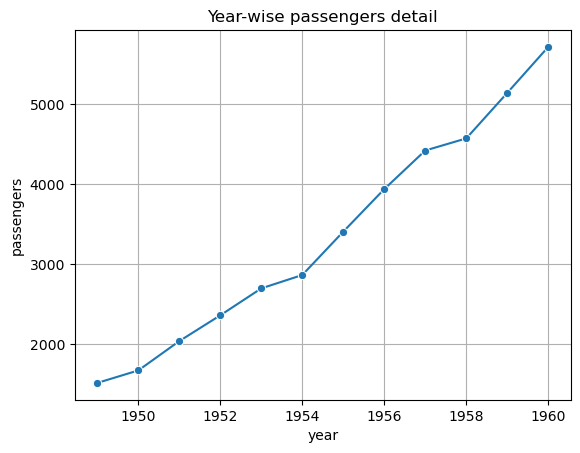

In [13]:
sns.lineplot(x='year' ,y ='passengers',data=timeline,marker='o')
plt.title('Year-wise passengers detail')
plt.grid(True)

# tips dataset

In [14]:
df=sns.load_dataset("tips")
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


# Scatter plot: correlation between 2 numerical variables

<Axes: xlabel='total_bill', ylabel='tip'>

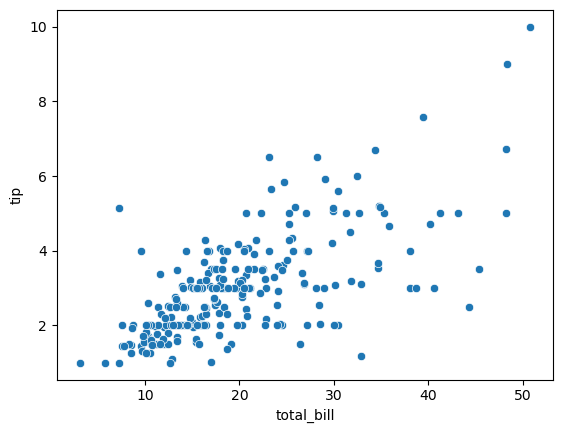

In [15]:
sns.scatterplot(x='total_bill',y='tip',data=df)

# Pair plot

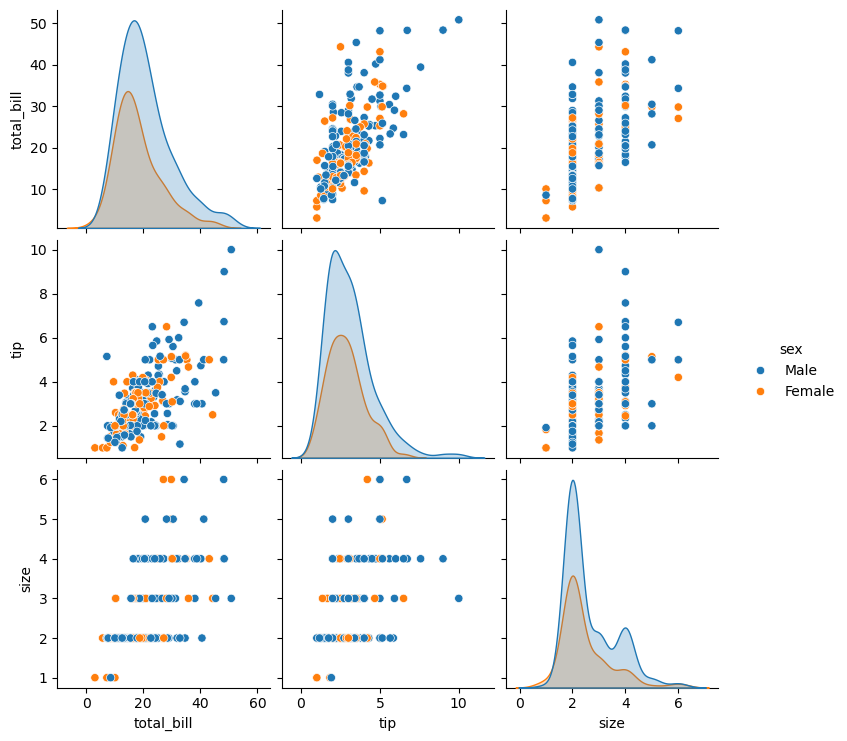

In [16]:
#Use; A pair plot  is a grid of scatter plots between all numerical variables
sns.pairplot(df,hue='sex')

# Heatmap

In [17]:
# Heatmap helps to visualize between many numerical variables / features.

# Why we are finding the correlation between variables .so that we can find the highly correlated features.
#In ML,we must remove one of the highly correlated feature to make ML model works better.(NOT OVERLOADING THE MODEL)

#correlation matrix : correlation between many numerical variables / features.
corr_matrix=df.corr(numeric_only=True)
corr_matrix

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

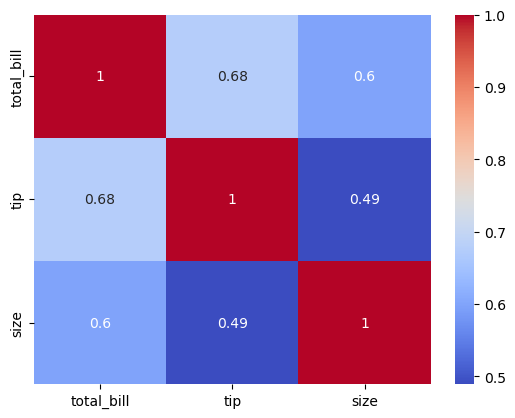

In [18]:
# Heatmap is nothing just the better visual representing of correlation matrix
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')

# Categorical feature relation: Pivot table + Heapmap

In [25]:
# Pivot table : Summaryy table of DF
# aggfun= size : count of male and femaleon particular day

pivot=df.pivot_table(index='time',columns='sex',aggfunc='size',observed=False)
pivot

sex,Male,Female
time,,
Lunch,33,35
Dinner,124,52


<Axes: xlabel='sex', ylabel='time'>

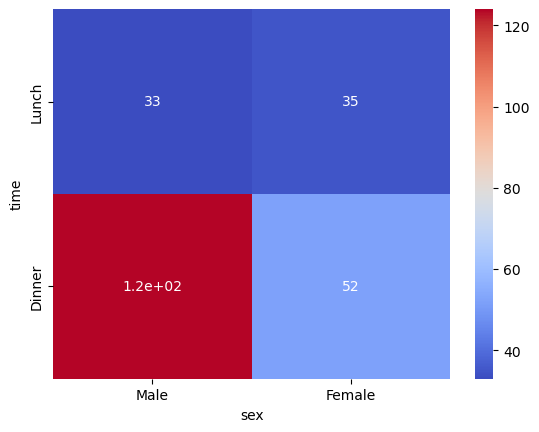

In [26]:
sns.heatmap(pivot,annot=True,cmap='coolwarm')

<Axes: xlabel='sex', ylabel='day'>

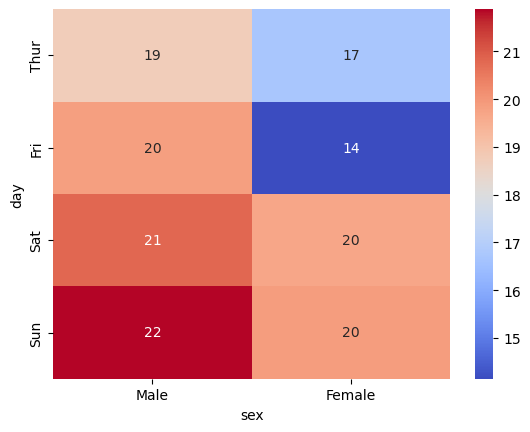

In [32]:
#Example-2

pivot=df.pivot_table(index='day',columns='sex',values='total_bill',aggfunc='mean',observed=False)
sns.heatmap(pivot,annot=True,cmap='coolwarm')

<Axes: xlabel='sex', ylabel='day-time'>

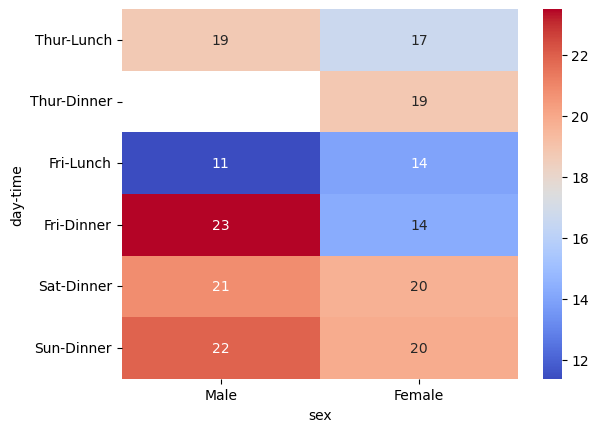

In [36]:
#Example-2 multiple index and single columns

pivot=df.pivot_table(index=['day','time'],columns='sex',values='total_bill',aggfunc='mean',observed=False)
sns.heatmap(pivot,annot=True,cmap='coolwarm')

<Axes: xlabel='sex-smoker', ylabel='day-time'>

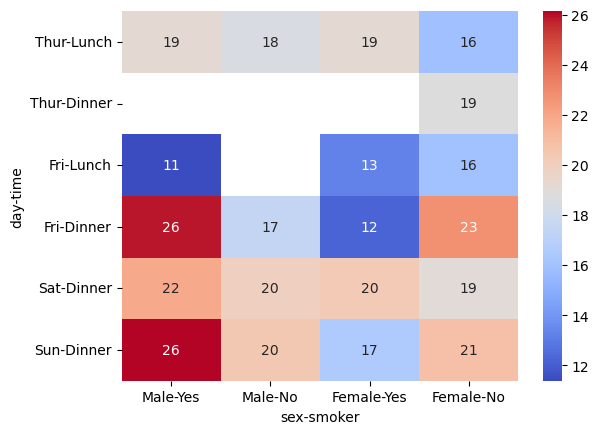

In [37]:
#Example-3 multiple index and multiple columns

pivot=df.pivot_table(index=['day','time'],columns=['sex','smoker'],values='total_bill',aggfunc='mean',observed=False)
sns.heatmap(pivot,annot=True,cmap='coolwarm')

# countplot () : shows frequency of categorical data 

<Axes: xlabel='smoker', ylabel='count'>

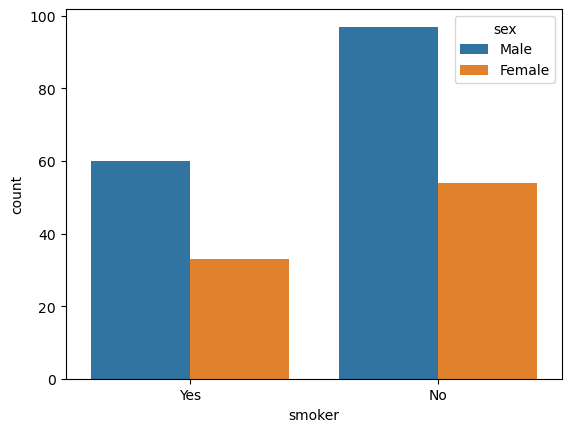

In [39]:
sns.countplot(data=df,x='smoker',hue='sex')

# Box plot

In [40]:
#Use : find Outliers and Skewness

<Axes: ylabel='tip'>

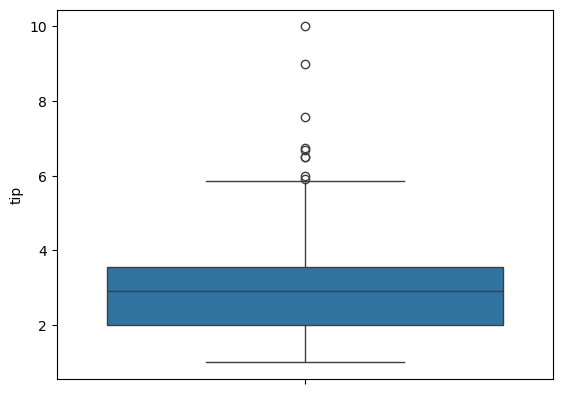

In [46]:
#Example-1
sns.boxplot(y='tip',data=df)

<Axes: xlabel='day', ylabel='tip'>

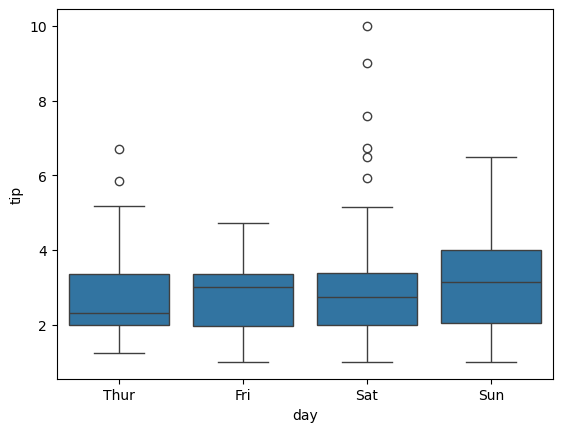

In [48]:
#Example-2
sns.boxplot(x='day',y='tip',data=df)

<Axes: xlabel='tip', ylabel='day'>

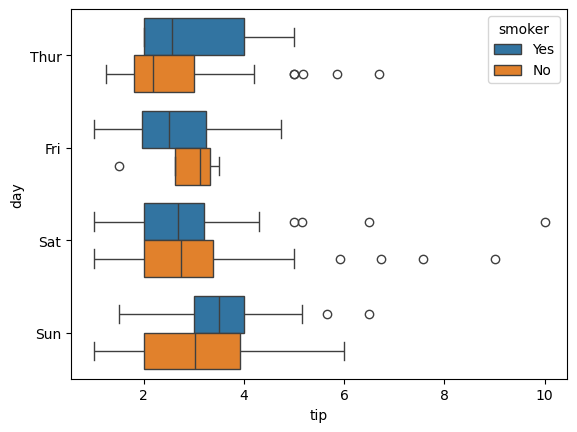

In [51]:
#Example-3
sns.boxplot(y='day',x='tip',data=df,hue='smoker')

<Axes: >

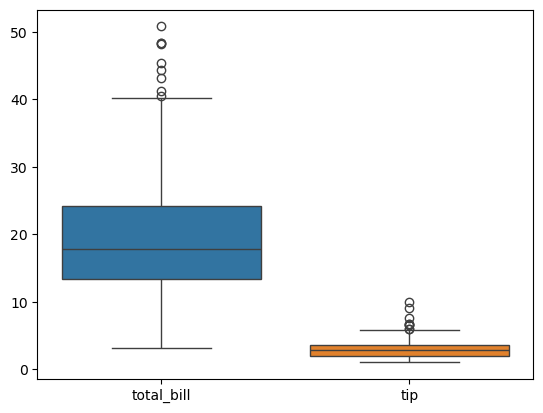

In [55]:
#Example-4 - plot multiple numerical coiumns
sns.boxplot(data=df[['total_bill','tip']])

# Density plot :(KDE plot) -kernel density estimate

<Axes: xlabel='total_bill', ylabel='Density'>

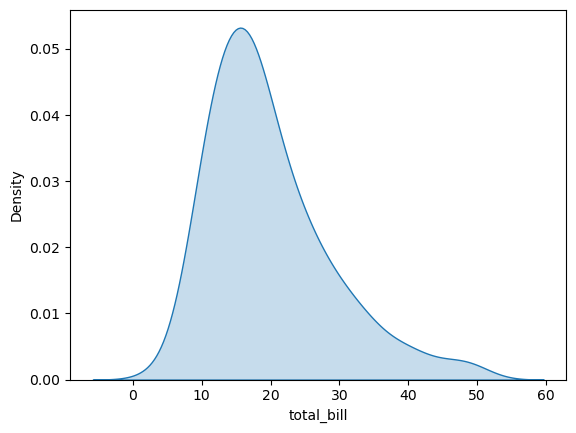

In [56]:
# Use : KDE plot is used to visualize probabilty of density function(PDF)
#PDF: This represented probability over a interval (range)

#Examplr: find the range of total bill which max people is paying
sns.kdeplot(data=df,x='total_bill',fill=True)

# Violin chart

<Axes: xlabel='day', ylabel='total_bill'>

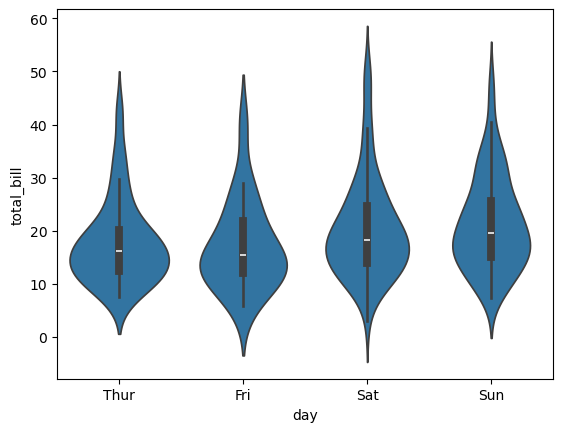

In [58]:
#violin chart : Box plot+ KDE Plot

sns.violinplot(x='day',y='total_bill',data=df)

# regression plot

<Axes: xlabel='total_bill', ylabel='tip'>

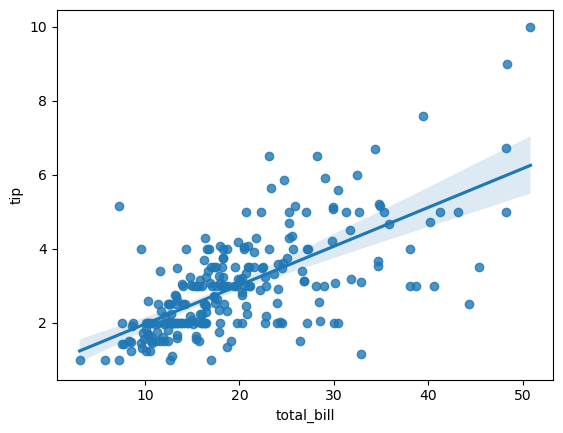

In [59]:
#Use:  his will plot the 'SImple linear regression ML ' model
sns.regplot(x='total_bill',y='tip',data=df)

# Facetgrid plot

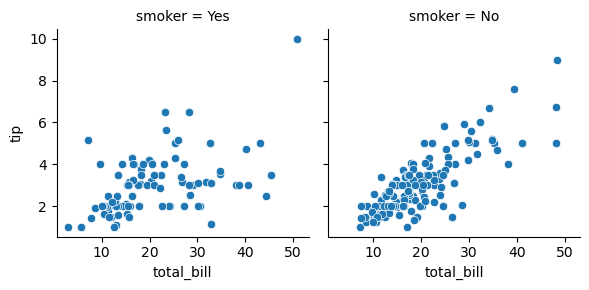

In [62]:
#Use : it is used for creating multiple subplots based upon sub-classes in categorical variable
g=sns.FacetGrid(df,col='smoker')
g.map_dataframe(sns.scatterplot,x='total_bill',y='tip')

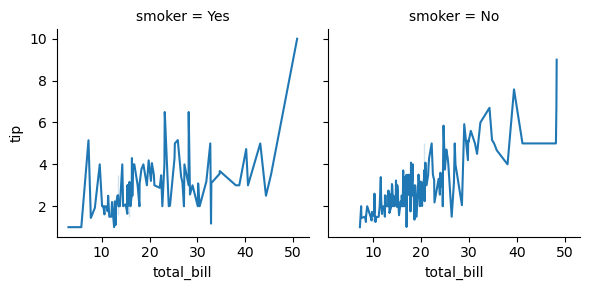

In [63]:
#Use : it is used for creating multiple subplots based upon sub-classes in categorical variable
g=sns.FacetGrid(df,col='smoker')
g.map_dataframe(sns.lineplot,x='total_bill',y='tip')

# joint plot

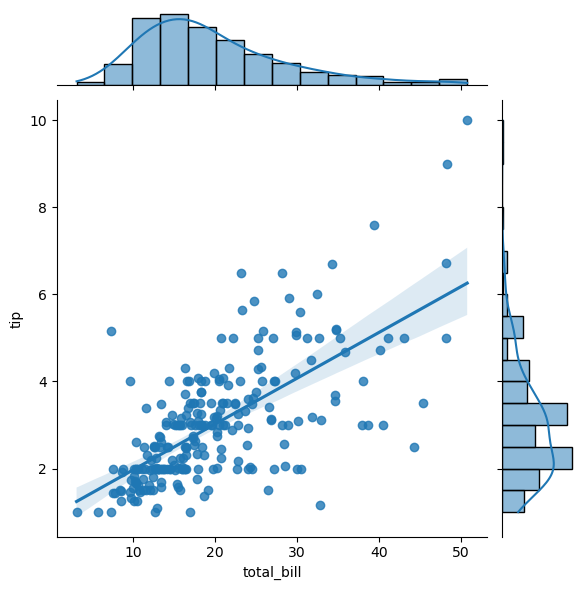

In [66]:
#Use : It is used for 
                  #  1.finding relationship between two numerical variables
                  #  2.It also shows the individual distribution of data
sns.jointplot(data=df,x='total_bill',y='tip',kind='reg')
